<a href="https://colab.research.google.com/github/mbryan56/Intro-Machine-Learning-Projects/blob/main/Homework_2_Intro_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model 1a: Theta = [  0.1703 801.8893   0.5379   0.2481   0.3568   0.1366]
Initial Train Loss: 12,548,220,228,880.9004
Final Train Loss: 1,609,779,457,184.7708 | Final Val Loss: 2,153,930,884,282.1223


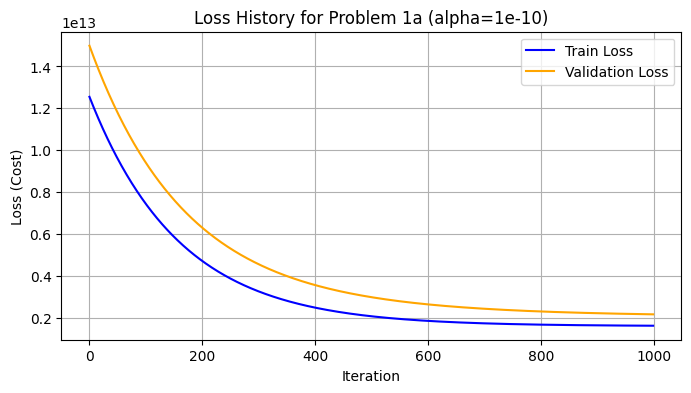

Model 1b: Theta = [  0.1703 801.8892   0.5379   0.2481   0.3568   0.1517   0.0396   0.0758
   0.0116   0.0777   0.1366   0.0509]
Initial Train Loss: 12,548,220,226,139.1289
Final Train Loss: 1,609,779,340,718.1785 | Final Val Loss: 2,153,930,763,541.3184


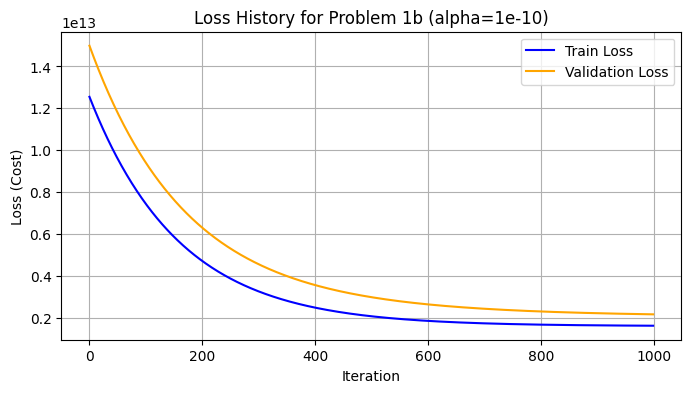

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

np.set_printoptions(precision=4, suppress=True)

# 1. Mount Drive & Load Data
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Intro to ML/Datasets/Housing.csv'
df = pd.read_csv(file_path)

# Map binary text columns to 1/0
varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[varlist] = df[varlist].apply(lambda x: x.map({'yes': 1, 'no': 0}))

vars_1a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
vars_1b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
           'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
           'parking', 'prefarea']

Y = df['price'].values
X1a = df[vars_1a].values
X1b = df[vars_1b].values

# 80/20 Split
X1a_train, X1a_val, Y_train, Y_val = train_test_split(X1a, Y, test_size=0.2, random_state=42)
X1b_train, X1b_val, _, _ = train_test_split(X1b, Y, test_size=0.2, random_state=42)

# Helper Functions
def compute_cost(X, Y, theta, lambda_reg=0):
    m = len(Y)
    predictions = X.dot(theta)
    errors = predictions - Y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    reg_penalty = (lambda_reg / (2 * m)) * np.sum(theta[1:] ** 2)
    return cost + reg_penalty

def gradient_descent(X_train, Y_train, X_val, Y_val, alpha, iterations, lambda_reg=0):
    m = len(Y_train)
    n = X_train.shape[1]
    theta = np.zeros(n)

    train_loss_history = []
    val_loss_history = []

    for _ in range(iterations):
        predictions = X_train.dot(theta)
        errors = predictions - Y_train

        gradient = (1 / m) * (X_train.T.dot(errors))
        if lambda_reg > 0:
            reg_term = (lambda_reg / m) * theta
            reg_term[0] = 0
            gradient += reg_term

        theta -= alpha * gradient

        train_loss = compute_cost(X_train, Y_train, theta, lambda_reg)
        val_loss = compute_cost(X_val, Y_val, theta, lambda_reg=0)

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

    return theta, train_loss_history, val_loss_history

# --- #Problem 1a ---
X1a_tr_b = np.c_[np.ones((len(X1a_train), 1)), X1a_train]
X1a_va_b = np.c_[np.ones((len(X1a_val), 1)), X1a_val]

alpha_1a = 1e-10
iterations_1a = 1000

theta_1a, train_loss_1a, val_loss_1a = gradient_descent(
    X1a_tr_b, Y_train, X1a_va_b, Y_val, alpha=alpha_1a, iterations=iterations_1a
)

print(f"Model 1a: Theta = {np.round(theta_1a, 4)}")
print(f"Initial Train Loss: {train_loss_1a[0]:,.4f}")
print(f"Final Train Loss: {train_loss_1a[-1]:,.4f} | Final Val Loss: {val_loss_1a[-1]:,.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_1a, color='blue', label='Train Loss')
plt.plot(val_loss_1a, color='orange', label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (Cost)')
plt.title(f'Loss History for Problem 1a (alpha={alpha_1a})')
plt.legend()
plt.grid(True)
plt.show()

# --- #Problem 1b ---
X1b_tr_b = np.c_[np.ones((len(X1b_train), 1)), X1b_train]
X1b_va_b = np.c_[np.ones((len(X1b_val), 1)), X1b_val]

alpha_1b = 1e-10
iterations_1b = 1000

theta_1b, train_loss_1b, val_loss_1b = gradient_descent(
    X1b_tr_b, Y_train, X1b_va_b, Y_val, alpha=alpha_1b, iterations=iterations_1b
)

print(f"Model 1b: Theta = {np.round(theta_1b, 4)}")
print(f"Initial Train Loss: {train_loss_1b[0]:,.4f}")
print(f"Final Train Loss: {train_loss_1b[-1]:,.4f} | Final Val Loss: {val_loss_1b[-1]:,.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_1b, color='blue', label='Train Loss')
plt.plot(val_loss_1b, color='orange', label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (Cost)')
plt.title(f'Loss History for Problem 1b (alpha={alpha_1b})')
plt.legend()
plt.grid(True)
plt.show()

Problem 2a Standardized - Final Train Loss: 675,004,510,848.4789 | Final Val Loss: 1,146,408,168,889.5422
Problem 2a Normalized   - Final Train Loss: 849,748,793,747.9463 | Final Val Loss: 1,458,033,578,362.7139


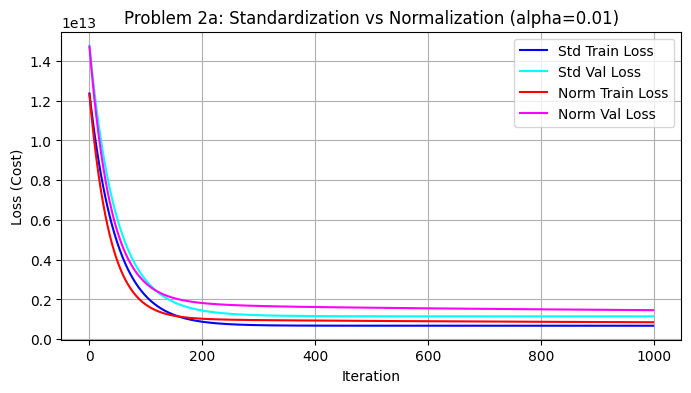

Problem 2b Standardized - Final Train Loss: 496,244,544,318.5421 | Final Val Loss: 900,111,363,844.0186
Problem 2b Normalized   - Final Train Loss: 640,942,055,907.6149 | Final Val Loss: 1,077,541,865,435.6562


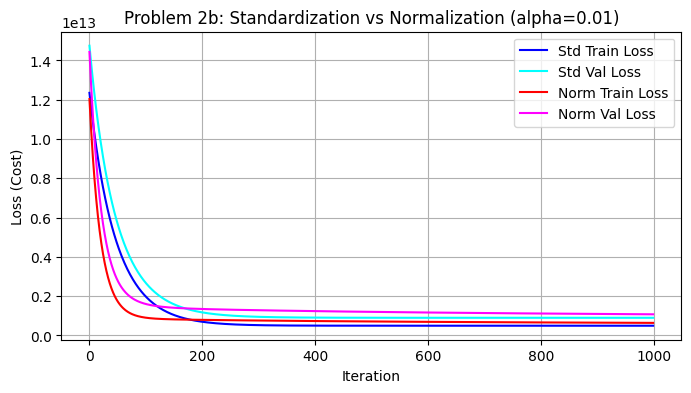

In [10]:
# --- #Problem 2a ---
scaler_std_a = StandardScaler()
scaler_norm_a = MinMaxScaler()

X2a_std_tr_b = np.c_[np.ones((len(X1a_train), 1)), scaler_std_a.fit_transform(X1a_train)]
X2a_std_va_b = np.c_[np.ones((len(X1a_val), 1)), scaler_std_a.transform(X1a_val)]

X2a_norm_tr_b = np.c_[np.ones((len(X1a_train), 1)), scaler_norm_a.fit_transform(X1a_train)]
X2a_norm_va_b = np.c_[np.ones((len(X1a_val), 1)), scaler_norm_a.transform(X1a_val)]

alpha_2 = 0.01
iterations_2 = 1000

theta_2a_std, train_loss_2a_std, val_loss_2a_std = gradient_descent(
    X2a_std_tr_b, Y_train, X2a_std_va_b, Y_val, alpha=alpha_2, iterations=iterations_2
)
theta_2a_norm, train_loss_2a_norm, val_loss_2a_norm = gradient_descent(
    X2a_norm_tr_b, Y_train, X2a_norm_va_b, Y_val, alpha=alpha_2, iterations=iterations_2
)

print(f"Problem 2a Standardized - Final Train Loss: {train_loss_2a_std[-1]:,.4f} | Final Val Loss: {val_loss_2a_std[-1]:,.4f}")
print(f"Problem 2a Normalized   - Final Train Loss: {train_loss_2a_norm[-1]:,.4f} | Final Val Loss: {val_loss_2a_norm[-1]:,.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_2a_std, color='blue', label='Std Train Loss')
plt.plot(val_loss_2a_std, color='cyan', label='Std Val Loss')
plt.plot(train_loss_2a_norm, color='red', label='Norm Train Loss')
plt.plot(val_loss_2a_norm, color='magenta', label='Norm Val Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (Cost)')
plt.title(f'Problem 2a: Standardization vs Normalization (alpha={alpha_2})')
plt.legend()
plt.grid(True)
plt.show()

# --- #Problem 2b ---
scaler_std_b = StandardScaler()
scaler_norm_b = MinMaxScaler()

X2b_std_tr_b = np.c_[np.ones((len(X1b_train), 1)), scaler_std_b.fit_transform(X1b_train)]
X2b_std_va_b = np.c_[np.ones((len(X1b_val), 1)), scaler_std_b.transform(X1b_val)]

X2b_norm_tr_b = np.c_[np.ones((len(X1b_train), 1)), scaler_norm_b.fit_transform(X1b_train)]
X2b_norm_va_b = np.c_[np.ones((len(X1b_val), 1)), scaler_norm_b.transform(X1b_val)]

theta_2b_std, train_loss_2b_std, val_loss_2b_std = gradient_descent(
    X2b_std_tr_b, Y_train, X2b_std_va_b, Y_val, alpha=alpha_2, iterations=iterations_2
)
theta_2b_norm, train_loss_2b_norm, val_loss_2b_norm = gradient_descent(
    X2b_norm_tr_b, Y_train, X2b_norm_va_b, Y_val, alpha=alpha_2, iterations=iterations_2
)

print(f"Problem 2b Standardized - Final Train Loss: {train_loss_2b_std[-1]:,.4f} | Final Val Loss: {val_loss_2b_std[-1]:,.4f}")
print(f"Problem 2b Normalized   - Final Train Loss: {train_loss_2b_norm[-1]:,.4f} | Final Val Loss: {val_loss_2b_norm[-1]:,.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_2b_std, color='blue', label='Std Train Loss')
plt.plot(val_loss_2b_std, color='cyan', label='Std Val Loss')
plt.plot(train_loss_2b_norm, color='red', label='Norm Train Loss')
plt.plot(val_loss_2b_norm, color='magenta', label='Norm Val Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (Cost)')
plt.title(f'Problem 2b: Standardization vs Normalization (alpha={alpha_2})')
plt.legend()
plt.grid(True)
plt.show()

Model 3a (Regularized Std): Theta = [4706324.1987  666301.3556  120262.9272  555141.1107  415871.5115
  287897.1452]
Initial Train Loss: 12,366,023,037,842.2734
Final Train Loss: 686,936,038,640.8206 | Final Val Loss: 1,152,281,027,945.8027


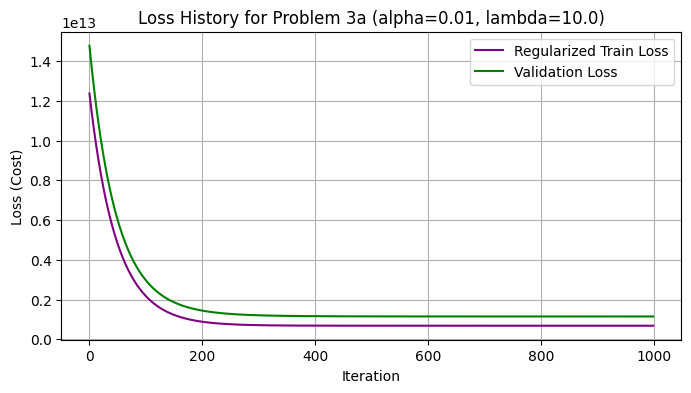

Model 3b (Regularized Std): Theta = [4706324.1987  512256.6596   68601.7462  519236.5697  355894.3921
  146998.7342   97942.1216  201006.5727  152346.5679  369826.5397
  212127.0442  265282.1801]
Initial Train Loss: 12,350,192,940,709.5820
Final Train Loss: 508,035,294,866.5312 | Final Val Loss: 903,438,881,402.8048


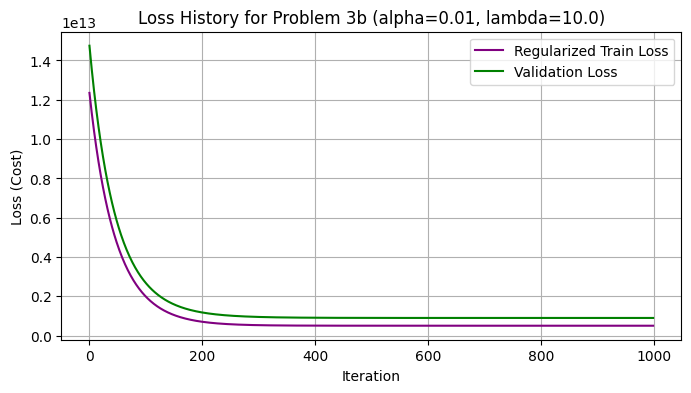

In [11]:
# --- #Problem 3a ---
lambda_3 = 10.0
theta_3a, train_loss_3a, val_loss_3a = gradient_descent(
    X2a_std_tr_b, Y_train, X2a_std_va_b, Y_val,
    alpha=alpha_2, iterations=iterations_2, lambda_reg=lambda_3
)

print(f"Model 3a (Regularized Std): Theta = {np.round(theta_3a, 4)}")
print(f"Initial Train Loss: {train_loss_3a[0]:,.4f}")
print(f"Final Train Loss: {train_loss_3a[-1]:,.4f} | Final Val Loss: {val_loss_3a[-1]:,.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_3a, color='purple', label='Regularized Train Loss')
plt.plot(val_loss_3a, color='green', label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (Cost)')
plt.title(f'Loss History for Problem 3a (alpha={alpha_2}, lambda={lambda_3})')
plt.legend()
plt.grid(True)
plt.show()

# --- #Problem 3b ---
theta_3b, train_loss_3b, val_loss_3b = gradient_descent(
    X2b_std_tr_b, Y_train, X2b_std_va_b, Y_val,
    alpha=alpha_2, iterations=iterations_2, lambda_reg=lambda_3
)

print(f"Model 3b (Regularized Std): Theta = {np.round(theta_3b, 4)}")
print(f"Initial Train Loss: {train_loss_3b[0]:,.4f}")
print(f"Final Train Loss: {train_loss_3b[-1]:,.4f} | Final Val Loss: {val_loss_3b[-1]:,.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_3b, color='purple', label='Regularized Train Loss')
plt.plot(val_loss_3b, color='green', label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss (Cost)')
plt.title(f'Loss History for Problem 3b (alpha={alpha_2}, lambda={lambda_3})')
plt.legend()
plt.grid(True)
plt.show()